# FlowDPS smoke test on Colab Pro+ A100

Project: `dps_flowdps` — AI-623 DVLM final project.

This notebook clones the official FlowDPS repo
(<https://github.com/FlowDPS-Inverse/FlowDPS>), downloads SD3 Medium
weights, and runs both **FlowDPS** and **PSLD** (latent-DPS) on a single
sample image as our first end-to-end smoke test.

**Pre-reqs (do these once before running this notebook):**
1. Colab Pro+ subscription, A100 runtime selected.
2. Hugging Face account + read token stored as the Colab secret `HF_TOKEN`.
3. SD3 Medium license accepted at <https://huggingface.co/stabilityai/stable-diffusion-3-medium>.
4. Google Drive mountable (you will be prompted in cell 3).


## 1. Confirm we have an A100

In [1]:
!nvidia-smi | head -10


Tue May 19 09:29:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             42W /  400W |       0MiB /  40960MiB |      0%      Default |


## 2. Mount Google Drive for persistent artifacts

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/dvlm_proj'
for sub in ['checkpoints', 'outputs', 'data', 'notebooks', 'logs']:
    os.makedirs(os.path.join(PROJECT_DIR, sub), exist_ok=True)
print('Project dir:', PROJECT_DIR)
!ls {PROJECT_DIR}


Mounted at /content/drive
Project dir: /content/drive/MyDrive/dvlm_proj
checkpoints  data  logs  notebooks  outputs


## 2b. Redirect the Hugging Face cache to Drive

SD3 Medium weights are ~6 GB. By default `huggingface_hub` caches them
to `/content/` (the VM's local disk), which is wiped when the runtime
disconnects. Point the cache at Drive so the weights are downloaded
once and reused across sessions.

This must run **before** any `from_pretrained(...)` or `login(...)`
call — env vars are read at HF library init.

In [3]:
import os
HF_CACHE = '/content/drive/MyDrive/dvlm_proj/checkpoints/hf_cache'
os.makedirs(HF_CACHE, exist_ok=True)
os.environ['HF_HOME'] = HF_CACHE
os.environ['HUGGINGFACE_HUB_CACHE'] = HF_CACHE
os.environ['TRANSFORMERS_CACHE'] = HF_CACHE
print('HF cache → Drive:', HF_CACHE)
!du -sh {HF_CACHE} 2>/dev/null || echo '(cache empty for now)'


HF cache → Drive: /content/drive/MyDrive/dvlm_proj/checkpoints/hf_cache
4.0K	/content/drive/MyDrive/dvlm_proj/checkpoints/hf_cache


## 3. Authenticate to Hugging Face (for SD3 weights)

In [4]:
from google.colab import userdata
from huggingface_hub import login
hf_token = userdata.get('HF_TOKEN')
assert hf_token and hf_token.startswith('hf_'), 'HF_TOKEN secret missing or malformed'
login(token=hf_token)
print('HF login OK')


HF login OK


## 4. Clone the FlowDPS repo and install its deps

We clone into `/content/FlowDPS` (the Colab VM's local disk, not Drive)
because pip installs and git operations are 10x faster on local SSD than
on Drive.

In [5]:
%cd /content
![ -d FlowDPS ] || git clone https://github.com/FlowDPS-Inverse/FlowDPS.git
%cd /content/FlowDPS
!git log -1 --oneline


/content
Cloning into 'FlowDPS'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 74 (delta 23), reused 29 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 7.89 MiB | 3.27 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/FlowDPS
8361843 (HEAD -> main, origin/main, origin/HEAD) Update README.md


In [6]:
# Install FlowDPS dependencies. Their requirements.txt pins CUDA 11.8
# torch, but Colab already ships with a CUDA 12.x torch — we skip the
# torch pin and install the rest.
import subprocess
with open('requirements.txt') as f:
    reqs = [l.strip() for l in f if l.strip() and not l.startswith('#')]
keep = [r for r in reqs if not r.lower().startswith(('torch', 'torchvision', 'torchaudio'))]
print('Installing:', keep)
subprocess.run(['pip', 'install', '--quiet'] + keep, check=True)
print('Done.')


Installing: ['accelerate==1.4.0', 'certifi==2025.1.31', 'charset-normalizer==3.4.1', 'diffusers==0.30.1', 'filelock==3.13.1', 'fsspec==2024.6.1', 'huggingface-hub==0.29.3', 'idna==3.10', 'importlib_metadata==8.6.1', 'Jinja2==3.1.4', 'MarkupSafe==2.1.5', 'mpmath==1.3.0', 'munch==4.0.0', 'networkx==3.3', 'numpy==2.1.2', 'nvidia-cublas-cu11==11.11.3.6', 'nvidia-cuda-cupti-cu11==11.8.87', 'nvidia-cuda-nvrtc-cu11==11.8.89', 'nvidia-cuda-runtime-cu11==11.8.89', 'nvidia-cudnn-cu11==9.1.0.70', 'nvidia-cufft-cu11==10.9.0.58', 'nvidia-curand-cu11==10.3.0.86', 'nvidia-cusolver-cu11==11.4.1.48', 'nvidia-cusparse-cu11==11.7.5.86', 'nvidia-nccl-cu11==2.20.5', 'nvidia-nvtx-cu11==11.8.86', 'packaging==24.2', 'pillow==11.1.0', 'protobuf==6.30.0', 'psutil==7.0.0', 'PyYAML==6.0.2', 'regex==2024.11.6', 'requests==2.32.3', 'safetensors==0.5.3', 'scipy==1.15.2', 'sentencepiece==0.2.0', 'sympy==1.13.1', 'tokenizers==0.21.0', 'tqdm==4.67.1', 'transformers==4.49.0', 'triton==3.0.0', 'typing_extensions==4.12.2'

## 5. Inspect the repo so we know the exact CLI we are about to use

In [7]:
!ls /content/FlowDPS
print('---')
!head -80 /content/FlowDPS/solve.py


assets	 functions  requirements.txt  sd3_sampler.py	  solve.py  utils
eval.py  README.md  samples	      solve_arbitrary.py  util.py
---
import argparse
from pathlib import Path
from typing import List

from munch import munchify
from PIL import Image
from tqdm import tqdm
import torch
from torchvision.utils import save_image
from torchvision import transforms

from util import set_seed, get_img_list, process_text
from sd3_sampler import get_solver
from functions.degradation import get_degradation

@torch.no_grad
def precompute(args, prompts:List[str], solver) -> List[torch.Tensor]:
    prompt_emb_set = []
    pooled_emb_set = []

    num_samples = args.num_samples if args.num_samples > 0 else len(prompts)
    for prompt in prompts[:num_samples]:
        prompt_emb, pooled_emb = solver.encode_prompt(prompt, batch_size=1)
        prompt_emb_set.append(prompt_emb)
        pooled_emb_set.append(pooled_emb)

    return prompt_emb_set, pooled_emb_set

def run(args):
    # load solver
    sol

In [8]:
!python /content/FlowDPS/solve.py --help 2>&1 | tail -60


Traceback (most recent call last):
  File "/content/FlowDPS/solve.py", line 9, in <module>
    from torchvision.utils import save_image
  File "/usr/local/lib/python3.12/dist-packages/torchvision/__init__.py", line 10, in <module>
    from torchvision import _meta_registrations, datasets, io, models, ops, transforms, utils  # usort:skip
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/_meta_registrations.py", line 163, in <module>
    @torch.library.register_fake("torchvision::nms")
     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/library.py", line 654, in register
    use_lib._register_fake(op_name, func, _stacklevel=stacklevel + 1)
  File "/usr/local/lib/python3.12/dist-packages/torch/library.py", line 154, in _register_fake
    handle = entry.abstract_impl.register(func_to_register, source)
             ^^^^^^^^^^^^^^^^^^^

## 6. Pick a sample image

The repo ships sample images under `samples/`. We'll use one of those
for the first smoke run — no FFHQ download needed yet.

In [9]:
import os
samples_dir = '/content/FlowDPS/samples'
print(os.listdir(samples_dir) if os.path.isdir(samples_dir) else 'samples/ not found')


['afhq_example.jpg', 'div2k_example.png', 'ffhq_example.png']


Found 3 candidate images
Will use: /content/FlowDPS/samples/afhq_example.jpg
Size: (512, 512)


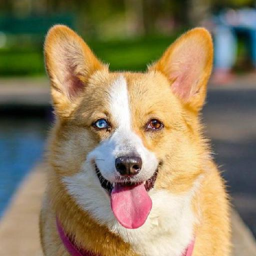

In [10]:
# Pick the first JPEG / PNG we can find.
import glob
candidates = sorted(
    glob.glob('/content/FlowDPS/samples/**/*.jpg', recursive=True)
    + glob.glob('/content/FlowDPS/samples/**/*.png', recursive=True)
    + glob.glob('/content/FlowDPS/samples/**/*.jpeg', recursive=True)
)
print(f'Found {len(candidates)} candidate images')
SAMPLE_IMG = candidates[0] if candidates else None
print('Will use:', SAMPLE_IMG)

# Show it inline
from PIL import Image
from IPython.display import display
if SAMPLE_IMG:
    img = Image.open(SAMPLE_IMG)
    print('Size:', img.size)
    display(img.resize((256, 256)))


## 7. Smoke run #1 — vanilla FlowDPS on Gaussian deblur

This is the moment of truth: does the canonical FlowDPS implementation
run end-to-end on Colab A100 for our image? We use the documented CLI:

```
python solve.py --img_size 768 --img_path <img> --prompt "..." \
                --task deblur_gauss --deg_scale 61 \
                --method flowdps --efficient_memory
```

The first run will also pull SD3 Medium weights from Hugging Face (~6 GB).
That download is one-time; subsequent runs reuse the cache.

In [11]:
OUT_DIR = '/content/drive/MyDrive/dvlm_proj/outputs/smoke_flowdps'
os.makedirs(OUT_DIR, exist_ok=True)

# The repo writes results into the current working directory by default,
# so we cd into a working dir, then move artifacts to Drive.
WORK_DIR = '/content/work_flowdps'
os.makedirs(WORK_DIR, exist_ok=True)
%cd /content/FlowDPS

PROMPT = 'a photo of a person'

import time
t0 = time.time()
!python solve.py \
    --img_size 768 \
    --img_path "{SAMPLE_IMG}" \
    --prompt "{PROMPT}" \
    --task deblur_gauss \
    --deg_scale 61 \
    --method flowdps \
    --efficient_memory
elapsed = time.time() - t0
print(f'FlowDPS run took {elapsed:.1f} s')


/content/FlowDPS
Traceback (most recent call last):
  File "/content/FlowDPS/solve.py", line 9, in <module>
    from torchvision.utils import save_image
  File "/usr/local/lib/python3.12/dist-packages/torchvision/__init__.py", line 10, in <module>
    from torchvision import _meta_registrations, datasets, io, models, ops, transforms, utils  # usort:skip
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/_meta_registrations.py", line 163, in <module>
    @torch.library.register_fake("torchvision::nms")
     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/library.py", line 654, in register
    use_lib._register_fake(op_name, func, _stacklevel=stacklevel + 1)
  File "/usr/local/lib/python3.12/dist-packages/torch/library.py", line 154, in _register_fake
    handle = entry.abstract_impl.register(func_to_register, source)
             ^^

In [12]:
# Find what the repo wrote and copy to Drive.
import shutil, glob
results = sorted(glob.glob('/content/FlowDPS/result*/**/*.png', recursive=True)) + \
          sorted(glob.glob('/content/FlowDPS/*.png'))
print('Wrote files:')
for r in results[-10:]: print(' ', r)

for r in results:
    shutil.copy(r, OUT_DIR)
print(f'Copied {len(results)} files into {OUT_DIR}')


Wrote files:
Copied 0 files into /content/drive/MyDrive/dvlm_proj/outputs/smoke_flowdps


## 8. Smoke run #2 — PSLD on the same image (our Latent-DPS baseline)

In [13]:
OUT_DIR_PSLD = '/content/drive/MyDrive/dvlm_proj/outputs/smoke_psld'
os.makedirs(OUT_DIR_PSLD, exist_ok=True)

import time
t0 = time.time()
!python solve.py \
    --img_size 768 \
    --img_path "{SAMPLE_IMG}" \
    --prompt "{PROMPT}" \
    --task deblur_gauss \
    --deg_scale 61 \
    --method psld \
    --efficient_memory
elapsed = time.time() - t0
print(f'PSLD run took {elapsed:.1f} s')


Traceback (most recent call last):
  File "/content/FlowDPS/solve.py", line 9, in <module>
    from torchvision.utils import save_image
  File "/usr/local/lib/python3.12/dist-packages/torchvision/__init__.py", line 10, in <module>
    from torchvision import _meta_registrations, datasets, io, models, ops, transforms, utils  # usort:skip
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/_meta_registrations.py", line 163, in <module>
    @torch.library.register_fake("torchvision::nms")
     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/library.py", line 654, in register
    use_lib._register_fake(op_name, func, _stacklevel=stacklevel + 1)
  File "/usr/local/lib/python3.12/dist-packages/torch/library.py", line 154, in _register_fake
    handle = entry.abstract_impl.register(func_to_register, source)
             ^^^^^^^^^^^^^^^^^^^

## 9. What did we measure?

If both runs completed cleanly, we now know:

- A100 + SD3 Medium fits in 40 GB VRAM with `--efficient_memory`.
- Wall-clock cost per image for FlowDPS and PSLD at this resolution / NFE
  setting (printed above).
- The output file structure the FlowDPS repo writes — we'll script
  around this for the full grid.

Next steps (back in the local repo):
1. Wrap `solve.py` invocation as a Python function that returns a tensor
   so we can plug it into our shared metric/CSV pipeline.
2. Download a real FFHQ-256 test set (start with ~50 images) and store
   under Drive's `data/ffhq/`.
3. Sweep zeta / NFE on a small validation subset.
